<a href="https://colab.research.google.com/github/Kashishkewat/AI-and-ML/blob/main/classification_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
data=pd.read_csv("/content/MagicTelescope.csv")

In [ ]:
data.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,FM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [ ]:
data.describe()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,FM3Trans,fAlpha,fDist
count,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000
mean,53.250154,22.180966,2.825017,0.380327,0.214657,-4.331745,10.545545,0.249726,27.645707,193.818026
std,42.364855,18.346056,0.472599,0.182813,0.110511,59.206062,51.000118,20.827439,26.103621,74.731787
min,4.283500,0.000000,1.941300,0.013100,0.000300,-457.916100,-331.780000,-205.894700,0.000000,1.282600
25%,24.336000,11.863800,2.477100,0.235800,0.128475,-20.586550,-12.842775,-10.849375,5.547925,142.492250
50%,37.147700,17.139900,2.739600,0.354150,0.196500,4.013050,15.314100,0.666200,17.679500,191.851450
75%,70.122175,24.739475,3.101600,0.503700,0.285225,24.063700,35.837800,10.946425,45.883550,240.563825
max,334.177000,256.382000,5.323300,0.893000,0.675200,575.240700,238.321000,179.851000,90.000000,495.561000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19020 entries, 0 to 19019
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   fLength   19020 non-null  float64
 1   fWidth    19020 non-null  float64
 2   fSize     19020 non-null  float64
 3   fConc     19020 non-null  float64
 4   fConc1    19020 non-null  float64
 5   fAsym     19020 non-null  float64
 6   fM3Long   19020 non-null  float64
 7   FM3Trans  19020 non-null  float64
 8   fAlpha    19020 non-null  float64
 9   fDist     19020 non-null  float64
 10  class     19020 non-null  object 
dtypes: float64(10), object(1)
memory usage: 1.6+ MB


In [ ]:
cleanup_nums={"class:":{"g":1,"h":0}}
data.replace(cleanup_nums,inplace=True)

In [ ]:
data.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,FM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [ ]:
from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)
simplefilter(action="ignore",category=Warning)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
import sklearn.metrics as metrics

In [ ]:
from sklearn import preprocessing
tdata=data
scaler=preprocessing.RobustScaler()


In [ ]:
dlist=list(tdata)
train=dlist[1:10]
predict=dlist[-1]
X=tdata[train]
Y=tdata[predict]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.3,random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(max_depth=10)
dt.fit(x_train,y_train)
dt_predict=dt.predict(x_test)
dtc=dt.score(x_test,y_test)
print(dtc)

0.8399929898352612


In [ ]:
print("classification report of decision tree")
print(classification_report(y_test,dt_predict))
print("confusion matrix of decision tree")
print(confusion_matrix(y_test,dt_predict))
print("accuracy of dt:",dtc*100)

classification report of decision tree
              precision    recall  f1-score   support

           g       0.84      0.93      0.88      3705
           h       0.84      0.67      0.75      2001

    accuracy                           0.84      5706
   macro avg       0.84      0.80      0.81      5706
weighted avg       0.84      0.84      0.84      5706

confusion matrix of decision tree
[[3452  253]
 [ 660 1341]]
accuracy of dt: 83.99929898352612


In [ ]:
dt_cf=confusion_matrix(y_test,dt_predict)


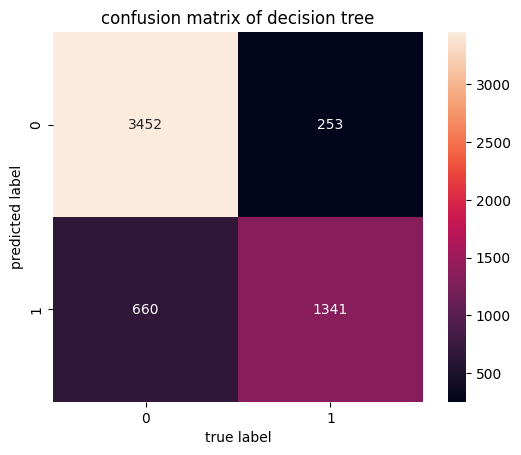

In [ ]:
sns.heatmap(dt_cf,annot=True,square=True,fmt='d',cbar=True)
plt.xlabel('true label')
plt.ylabel('predicted label')
plt.title('confusion matrix of decision tree')
plt.show()

# Random forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf=RandomForestClassifier(n_estimators=100,n_jobs=-1,oob_score=True,bootstrap=True,max_features="sqrt")
rf.fit(x_train,y_train.values.ravel())
rf_predict=rf.predict(x_test)
rfc=rf.score(x_test,y_test)
print(rfc)

0.8710129688047669


In [ ]:
print("classification report of random forest")
print("accuracy of rfc:",rfc*100)
print(classification_report(y_test,rf_predict))

classification report of random forest
accuracy of rfc: 87.10129688047668
              precision    recall  f1-score   support

           g       0.88      0.93      0.90      3705
           h       0.86      0.76      0.80      2001

    accuracy                           0.87      5706
   macro avg       0.87      0.84      0.85      5706
weighted avg       0.87      0.87      0.87      5706



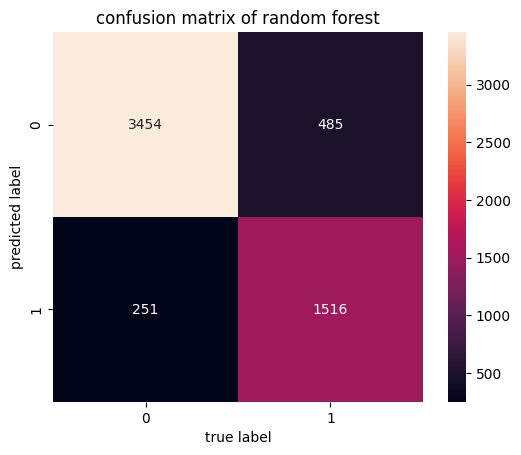

In [ ]:
rf_cf=confusion_matrix(y_test,rf_predict)
sns.heatmap(rf_cf.transpose(),annot=True,square=True,fmt='d',cbar=True)
plt.xlabel('true label')
plt.ylabel('predicted label')
plt.title('confusion matrix of random forest')
plt.show()
#

# Linear Support Vector Machine

In [ ]:
data_scaled=data

In [ ]:
from sklearn.svm import LinearSVC
sv=LinearSVC(max_iter=10000)
sv.fit(x_train,y_train.values.ravel())
sv_predicted=sv.predict(x_test)
svs=sv.score(x_test,y_test)
print(svs)

0.777602523659306


In [ ]:
print("classification report of support vector machine")
print("accuracy of sv:",svs*100,"%\n")
print(classification_report(y_test,sv_predicted))

classification report of support vector machine
accuracy of sv: 77.7602523659306 %

              precision    recall  f1-score   support

           g       0.79      0.90      0.84      3705
           h       0.74      0.56      0.64      2001

    accuracy                           0.78      5706
   macro avg       0.77      0.73      0.74      5706
weighted avg       0.77      0.78      0.77      5706



In [ ]:
sv_cf=confusion_matrix(y_test,sv_predicted)
print(sv_cf)

[[3323  382]
 [ 887 1114]]


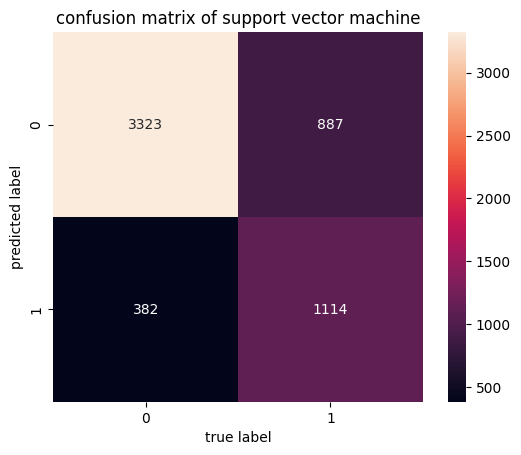

In [ ]:
sns.heatmap(sv_cf.transpose(),annot=True,square=True,fmt='d',cbar=True)
plt.xlabel('true label')
plt.ylabel('predicted label')
plt.title('confusion matrix of support vector machine')
plt.show()

# Naive Bayes Classifier

In [ ]:
import pandas as pd
data=pd.read_csv("/content/MagicTelescope.csv")
data_norm = data

In [ ]:
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
nb.fit(x_train,y_train.values.ravel())
nb_predicted=nb.predict(x_test)
nbs=nb.score(x_test,y_test)
print(nbs)

0.7367683140553803


In [ ]:
print("classification report of naive bayes")
print("accuracy of naive bayes classifier:",nbs*100,"%\n")
print(classification_report(y_test,nb_predicted))

classification report of naive bayes
accuracy of naive bayes classifier: 73.67683140553804 %

              precision    recall  f1-score   support

           g       0.74      0.93      0.82      3705
           h       0.74      0.38      0.50      2001

    accuracy                           0.74      5706
   macro avg       0.74      0.66      0.66      5706
weighted avg       0.74      0.74      0.71      5706



Text(0.5, 1.0, 'cofusion matrix of naive bayes')

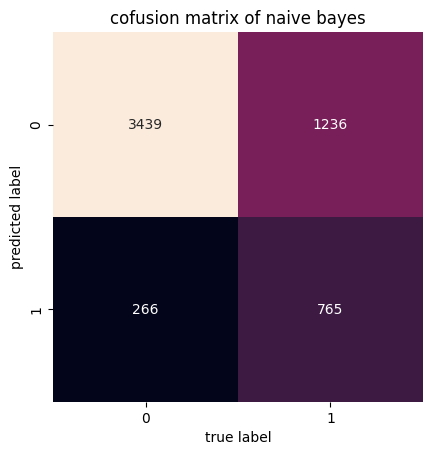

In [ ]:
nb_cf=confusion_matrix(y_test,nb_predicted)
sns.heatmap(nb_cf.transpose(),annot=True,square=True,fmt="d",cbar=False)
plt.xlabel("true label")
plt.ylabel("predicted label")
plt.title("cofusion matrix of naive bayes")

In [ ]:
rf_tp=rf_cf[0][0]
rf_fp=rf_cf[0][1]
rf_fn=rf_cf[1][0]
rf_tn=rf_cf[1][1]


In [ ]:
rf_tp=rf_tp.astype(float)
rf_fp=rf_fp.astype(float)
rf_fn=rf_fn.astype(float)
rf_tn=rf_tn.astype(float)

In [ ]:
rf_tpr=rf_tp/(rf_tp+rf_fn)
rf_fpr=rf_fp/(rf_fp+rf_tn)
#specificity
rf_tnr=rf_tn/(rf_tn+rf_fp)
#precision
rf_pre=rf_tp/(rf_tp+rf_fp)
#accuracy
rf_acc=(rf_tp+ rf_tn)/(rf_tp+rf_fp+rf_fn+rf_tn)

In [ ]:
print("true positive rate of random forest:",rf_tpr)
print("false positive rate of random forest:",rf_fpr)

true positive rate of random forest: 0.8768723026148769
false positive rate of random forest: 0.1420486700622524
